In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from PPairS.constants import collated_results_path as clp
from PPairS.utils import families

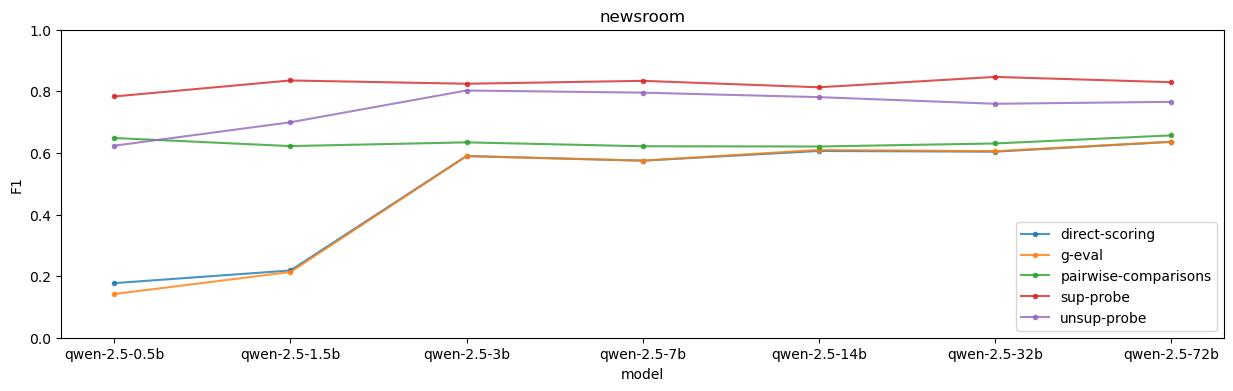

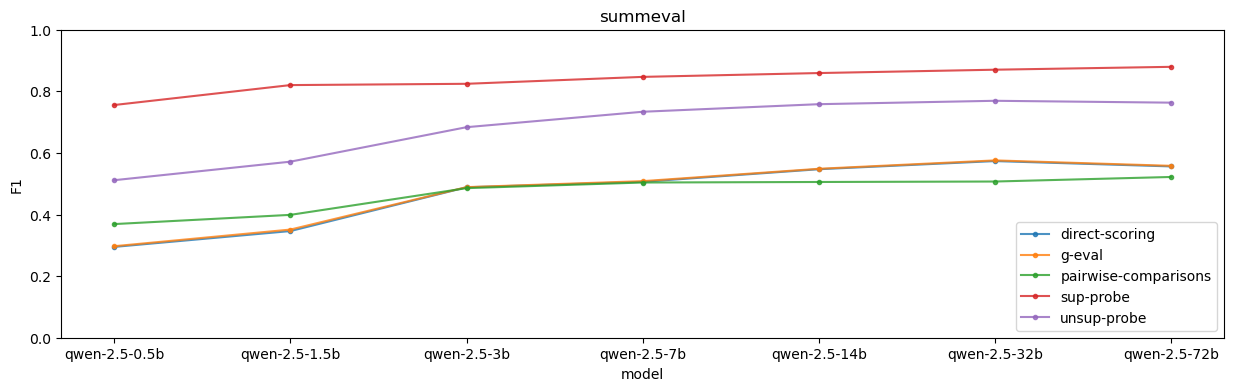

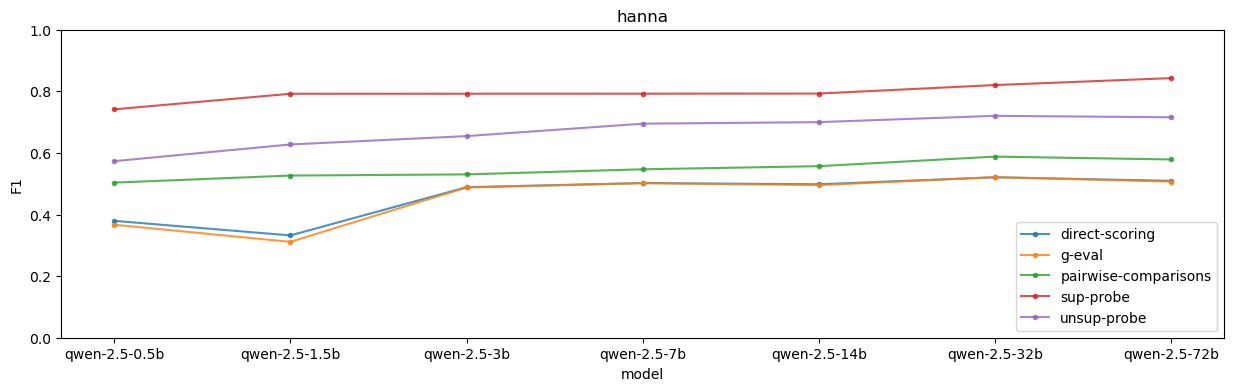

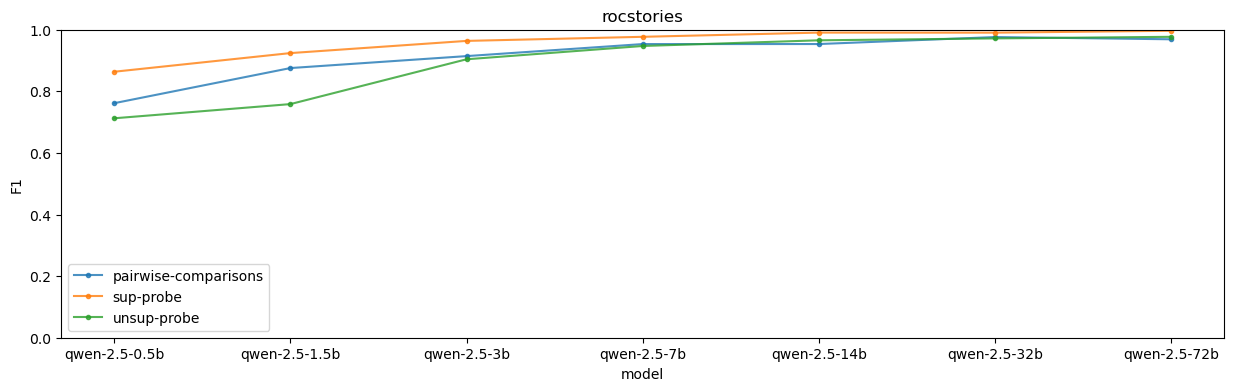

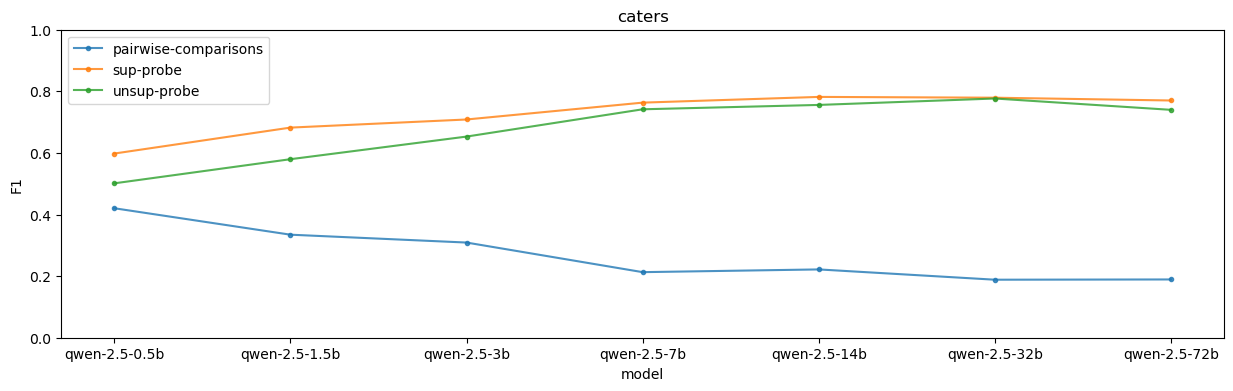

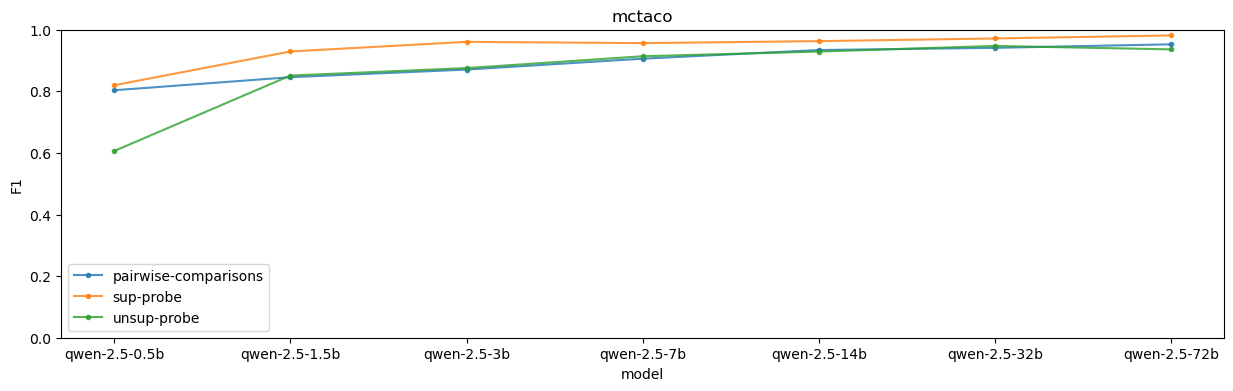

In [9]:
models = families['qwen']

for dataset in ['newsroom', 'summeval', 'hanna']:
# for dataset in ['newsroom']:
    probe_s = pd.read_json(f'{clp}/{dataset}/probe_s_results.jsonl', orient='records', lines=True).set_index('model')
    probe_u = pd.read_json(f'{clp}/{dataset}/probe_u_results.jsonl', orient='records', lines=True).set_index('model')
    prompting = pd.read_json(f'{clp}/{dataset}/results.jsonl', orient='records', lines=True).set_index('model')
    ds = prompting[prompting['method'] == 'direct_scoring'].loc[models, 'avg_f1'].values
    ge = prompting[prompting['method'] == 'g_eval'].loc[models, 'avg_f1'].values
    pc = prompting[prompting['method'] == 'pairwise_comparisons'].loc[models, 'avg_f1'].values
    sup = probe_s.loc[models, 'avg_f1'].values
    unsup = probe_u.loc[models, 'avg_f1'].values
    fig, ax = plt.subplots(figsize=(15, 4))
    for scores, label in zip([ds, ge, pc, sup, unsup], ['direct-scoring', 'g-eval', 'pairwise-comparisons', 'sup-probe', 'unsup-probe']):
        ax.plot(scores, label=label, alpha=0.8, marker='.')
    ax.set_xticks(range(len(models)), models)
    ax.set_xlabel('model'); ax.set_ylabel('F1')
    ax.legend()
    ax.set_ylim(0, 1)
    ax.set_title(dataset)
    plt.show()

dataset = 'rocstories'
probe_s = pd.read_json(f'{clp}/{dataset}/probe_s_results.jsonl', orient='records', lines=True).set_index('model')
probe_u = pd.read_json(f'{clp}/{dataset}/probe_u_results.jsonl', orient='records', lines=True).set_index('model')
prompting = pd.read_json(f'{clp}/{dataset}/results.jsonl', orient='records', lines=True).set_index('model')
pc = prompting.loc[models, 'f1'].values
sup = probe_s.loc[models, 'avg_f1'].values
unsup = probe_u.loc[models, 'avg_f1'].values
fig, ax = plt.subplots(figsize=(15, 4))
for scores, label in zip([pc, sup, unsup], ['pairwise-comparisons', 'sup-probe', 'unsup-probe']):
    ax.plot(scores, label=label, alpha=0.8, marker='.')
ax.set_xticks(range(len(models)), models)
ax.set_xlabel('model'); ax.set_ylabel('F1')
ax.legend()
ax.set_ylim(0, 1)
ax.set_title(dataset)
plt.show()

for dataset in ['caters', 'mctaco']:
    probe_s = pd.read_json(f'{clp}/{dataset}/probe_s_results.jsonl', orient='records', lines=True).set_index('model')
    probe_u = pd.read_json(f'{clp}/{dataset}/probe_u_results.jsonl', orient='records', lines=True).set_index('model')
    prompting = pd.read_json(f'{clp}/{dataset}/results.jsonl', orient='records', lines=True).set_index('model')
    pc = prompting.loc[models, 'f1'].values
    sup = probe_s.loc[models, 'f1'].values
    unsup = probe_u.loc[models, 'f1'].values
    fig, ax = plt.subplots(figsize=(15, 4))
    for scores, label in zip([pc, sup, unsup], ['pairwise-comparisons', 'sup-probe', 'unsup-probe']):
        ax.plot(scores, label=label, alpha=0.8, marker='.')
    ax.set_xticks(range(len(models)), models)
    ax.set_xlabel('model'); ax.set_ylabel('F1')
    ax.legend()
    ax.set_ylim(0, 1)
    ax.set_title(dataset)
    plt.show()